# Advanced DiSC Stability Analysis Notebook

This notebook implements a more realistic **Stability Index (SI)** model for the
Digital Skull Clamp (DiSC), combining both twisting moments and uneven pin depths.

## Mathematical Model & Key Formulas

1. **Moment about z-axis**  
$$
M_z = \sum_{i=1}^3 \bigl(\mathbf{r}_i \times \mathbf{F}_i\bigr)_z
$$

2. **Penetration depth** per pin and range:  
$$
d_i = k_{\rm depth} \; |F_i|,
\quad \Delta d = \max_i d_i - \min_i d_i
$$

3. **Stability Index (SI)**:  
$$
SI = \exp\biggl(-\frac{|M_z|}{M_{\rm crit}}\biggr) \times \exp\biggl(-\frac{\Delta d}{d_{\rm crit}}\biggr)
$$


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def evaluate_clamp_basic(forces_N, phis_deg,
                         skull_R=85.0,
                         k_depth=0.04,
                         Mcrit=50.0,
                         dcrit=1.0):
    """
    Compute the Stability Index (SI) for a three-pin clamp.
    Inputs:
      - forces_N: [F1, F2, F3] forces from sensors (N)
      - phis_deg: [ϕ1, ϕ2, ϕ3] pin angles from tracker (deg)
      - skull_R: radius of skull (mm)
      - k_depth: mm of penetration per N of force
      - Mcrit: moment scaling constant
      - dcrit: depth-range scaling constant
    Returns:
      - SI: stability index (0–1)
    """
    phis = np.deg2rad(phis_deg)
    r = np.stack([
        skull_R * np.cos(phis),
        skull_R * np.sin(phis),
        np.zeros_like(phis)
    ], axis=1)
    r_hat = r / np.linalg.norm(r, axis=1)[:, None]
    forces = np.asarray(forces_N, float)
    F_vec = np.array([-forces[i] * r_hat[i] for i in range(3)])
    Mz = np.cross(r, F_vec)[:, 2].sum()
    depths = k_depth * np.abs((F_vec * r_hat).sum(axis=1))
    delta_d = depths.ptp()
    SI = np.exp(-abs(Mz) / Mcrit) * np.exp(-delta_d / dcrit)
    return SI


### Why this model?
- **Twisting force (moment)**: captures how pins can twist the clamp off if forces are unbalanced.
- **Penetration depth**: ensures all pins sink equally; uneven depths let the clamp wobble.
- **Combined index**: SI goes down if either twisting or depth imbalance grows.

### What is penetration depth?
- When you push a pin in with some force, it sinks a bit into the skull.
- We **estimate** that sink amount by:  
  $$d_i = k_{\rm depth}\times F_i$$  
  where **k_depth** (e.g. 0.04 mm/N) converts force to millimeters of penetration.
- The difference $$\Delta d = \max_i d_i - \min_i d_i$$ shows how unevenly the pins sit.


In [11]:
# Single-case examples
SI_sym = evaluate_clamp_basic([100,100,100], [0,120,240])
# Asymmetric case
SI_asym = evaluate_clamp_basic([50,100,100], [0,120,240])
print(f"Symmetric SI  = {SI_sym:.3f}")
print(f"Asymmetric SI = {SI_asym:.3f}")

Symmetric SI  = 1.000
Asymmetric SI = 0.135


In [12]:
# Test unequal forces
for forces in ([100,100,100], [50,200,120], [100,50,150]):
    SI = evaluate_clamp_basic(forces, [0, 120, 240])
    print(f"Forces = {forces}, SI = {SI:.4f}")


Forces = [100, 100, 100], SI = 1.0000
Forces = [50, 200, 120], SI = 0.0025
Forces = [100, 50, 150], SI = 0.0183


## 3D Stability Surface
Fix Pin C = 120 N, vary forces on A/B, and see SI change.

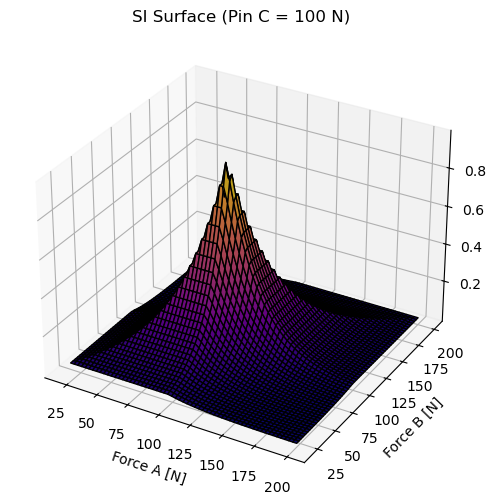

In [16]:
force_min, force_max, N = 20, 200, 60
fA = np.linspace(force_min, force_max, N)
fB = np.linspace(force_min, force_max, N)
FA, FB = np.meshgrid(fA, fB)
FC = 100.0
Z = np.zeros_like(FA)
for i in range(N):
    for j in range(N):
        Z[i,j] = evaluate_clamp_basic([FA[i,j], FB[i,j], FC], [0,120,240])
norm_Z = (Z - Z.min())/(Z.max()-Z.min())
colors = plt.cm.plasma(norm_Z)
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(FA, FB, Z, facecolors=colors, rstride=1, cstride=1, edgecolor='k')
ax.set_xlabel('Force A [N]')
ax.set_ylabel('Force B [N]')
ax.set_zlabel('SI')
ax.set_title('SI Surface (Pin C = 100 N)')
plt.show()

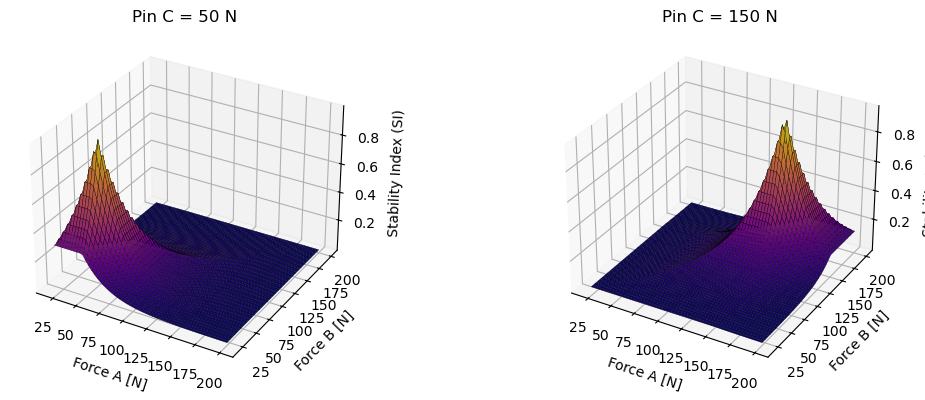

In [21]:
# 3D Stability Surfaces for two Pin C values in subplots
import numpy as np
import matplotlib.pyplot as plt

force_min, force_max, N = 20, 200, 60
fA = np.linspace(force_min, force_max, N)
fB = np.linspace(force_min, force_max, N)
FC_values = [50.0, 150.0]

fig = plt.figure(figsize=(12, 4))

for idx, FC in enumerate(FC_values, start=1):
    # Build grid
    FA, FB = np.meshgrid(fA, fB)
    Z = np.zeros_like(FA)
    for i in range(N):
        for j in range(N):
            Z[i, j] = evaluate_clamp_basic([FA[i, j], FB[i, j], FC],
                                           [0, 120, 240])
    # Normalize for coloring
    norm_Z = (Z - Z.min()) / (Z.max() - Z.min())
    colors = plt.cm.plasma(norm_Z)

    # Create 3D subplot
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    ax.plot_surface(FA, FB, Z,
                    facecolors=colors,
                    rstride=1, cstride=1,
                    edgecolor='k', linewidth=0.2, antialiased=True)
    ax.set_xlabel('Force A [N]')
    ax.set_ylabel('Force B [N]')
    ax.set_zlabel('Stability Index (SI)')
    ax.set_title(f'Pin C = {FC:.0f} N')

plt.tight_layout()
plt.show()
